In [1]:
# Retail & Marketing Analytics Project
# Part 4: Customer Segmentation and Advanced Analytics

"""
Project: Retail & Marketing Analytics - Customer Segmentation & Sales Optimization
Notebook: 04 - Customer Segmentation and Advanced Analytics


Objective:
- RFM Analysis (Recency, Frequency, Monetary)
- K-Means Clustering for customer segmentation
- Cluster profiling and characterization
- Market Basket Analysis - Assignments
- Cohort Analysis
- Customer Lifetime Value (CLV) calculation
"""

# ============================================================================
# 1. IMPORT LIBRARIES AND LOAD DATA
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Market Basket Analysis
#pip install mlxtend
try:
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    MBA_AVAILABLE = True
except ImportError:
    MBA_AVAILABLE = False
    print("mlxtend not installed. Run: pip install mlxtend")

from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv('data/processed/cleaned_retail_sales.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'])

print("="*80)
print("CUSTOMER SEGMENTATION AND ADVANCED ANALYTICS")
print("="*80)
print(f"\nDataset Shape: {df.shape}")


mlxtend not installed. Run: pip install mlxtend
CUSTOMER SEGMENTATION AND ADVANCED ANALYTICS

Dataset Shape: (10000, 45)


In [2]:
# ============================================================================
# 2. RFM ANALYSIS (RECENCY, FREQUENCY, MONETARY)
# ============================================================================

print("\n" + "="*80)
print("RFM ANALYSIS")
print("="*80)

# Set analysis date (day after last transaction)
analysis_date = df['Order_Date'].max() + timedelta(days=1)
print(f"\nAnalysis Date: {analysis_date.date()}")

# Calculate RFM metrics for each customer
rfm = df.groupby('Customer_ID').agg({
    'Order_Date': lambda x: (analysis_date - x.max()).days,  # Recency
    'Order_ID': 'count',  # Frequency
    'Sales': 'sum'  # Monetary
}).reset_index()

rfm.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']

print(f"\n RFM Metrics Calculated for {len(rfm):,} customers")
print("\nRFM Summary Statistics:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

# Create RFM scores (1-5 scale, where 5 is best)
print("\n Creating RFM Scores...")
# Recency Score (lower is better, so reverse)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1], duplicates='drop')

# Frequency Score (higher is better)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, 
                         labels=[1, 2, 3, 4, 5], duplicates='drop')

# Monetary Score (higher is better)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5], duplicates='drop')

# Combined RFM Score
rfm['RFM_Score'] = (rfm['R_Score'].astype(str) + 
                    rfm['F_Score'].astype(str) + 
                    rfm['M_Score'].astype(str))

# Numeric RFM Score (average)
rfm['RFM_Score_Numeric'] = (rfm['R_Score'].astype(int) + 
                            rfm['F_Score'].astype(int) + 
                            rfm['M_Score'].astype(int)) / 3
print("✓ RFM Scores Created")

# Customer Segmentation based on RFM
def segment_customers(row):
    """Segment customers based on RFM scores"""
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])
    
    # Champions: Best customers
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    # Loyal Customers: Buy regularly
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    # Potential Loyalists: Recent customers with potential
    elif r >= 4 and f <= 2 and m >= 3:
        return 'Potential Loyalists'
    # New Customers: Recent first-time buyers
    elif r >= 3 and f <= 2:
        return 'New Customers'
    # Promising: Recent but low spenders
    elif r >= 3 and m <= 2:
        return 'Promising'
    # Need Attention: Above average recency, frequency, and monetary
    elif r == 3 and f == 3 and m == 3:
        return 'Need Attention'
    # About to Sleep: Below average engagement
    elif r <= 2 and f <= 2:
        return 'About to Sleep'
    # At Risk: Used to be good, now declining
    elif r <= 2 and f >= 3:
         return 'At Risk'
    # Can't Lose Them: Were best customers but churning
    elif r <= 2 and f >= 4 and m >= 4:
        return "Can't Lose Them"
    # Lost: Long time since purchase
    elif r == 1:
        return 'Lost'
    else:
        return 'Others'

rfm['Customer_Segment'] = rfm.apply(segment_customers, axis=1)

print("\n Customer Segmentation Complete:")
print(rfm['Customer_Segment'].value_counts())

# Visualize RFM segments
fig = px.pie(rfm['Customer_Segment'].value_counts().reset_index(), 
             values='count', 
             names='Customer_Segment',
             title='Customer Distribution by RFM Segments',
             hole=0.4,
             color_discrete_sequence=px.colors.qualitative.Set3)
fig.write_html('outputs/figures/17_rfm_segments.html')
print("✓ Saved: 17_rfm_segments.html")
# RFM Summary by Segment
rfm_summary = rfm.groupby('Customer_Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Customer_ID': 'count'
}).round(2)
rfm_summary.columns = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Customer_Count']
rfm_summary['Revenue_Contribution'] = (rfm.groupby('Customer_Segment')['Monetary'].sum() / 
                                        rfm['Monetary'].sum() * 100).round(2)
rfm_summary = rfm_summary.sort_values('Revenue_Contribution', ascending=False)

print("\n RFM Segment Summary:")
print(rfm_summary)

# Save RFM analysis
rfm.to_csv('data/processed/rfm_analysis.csv', index=False)
print("\n✓ RFM analysis saved to: data/processed/rfm_analysis.csv")


RFM ANALYSIS

Analysis Date: 2023-02-22

 RFM Metrics Calculated for 1,986 customers

RFM Summary Statistics:
           Recency    Frequency     Monetary
count  1986.000000  1986.000000  1986.000000
mean     81.605740     5.035247   543.137452
std      77.074769     2.256983   282.191515
min       1.000000     1.000000    13.521954
25%      24.000000     3.000000   330.710807
50%      58.000000     5.000000   516.372006
75%     114.000000     6.000000   716.082448
max     408.000000    14.000000  1706.776827

 Creating RFM Scores...
✓ RFM Scores Created

 Customer Segmentation Complete:
Customer_Segment
About to Sleep         446
Loyal Customers        401
Champions              353
At Risk                344
New Customers          289
Promising               93
Potential Loyalists     60
Name: count, dtype: int64
✓ Saved: 17_rfm_segments.html

 RFM Segment Summary:
                     Avg_Recency  Avg_Frequency  Avg_Monetary  Customer_Count  \
Customer_Segment                      


K-MEANS CLUSTERING

Features for clustering: ['Recency', 'Frequency', 'Monetary']
Data shape: (1986, 3)
✓ Features standardized

 Determining Optimal Number of Clusters...
✓ Saved: 18_optimal_clusters.png


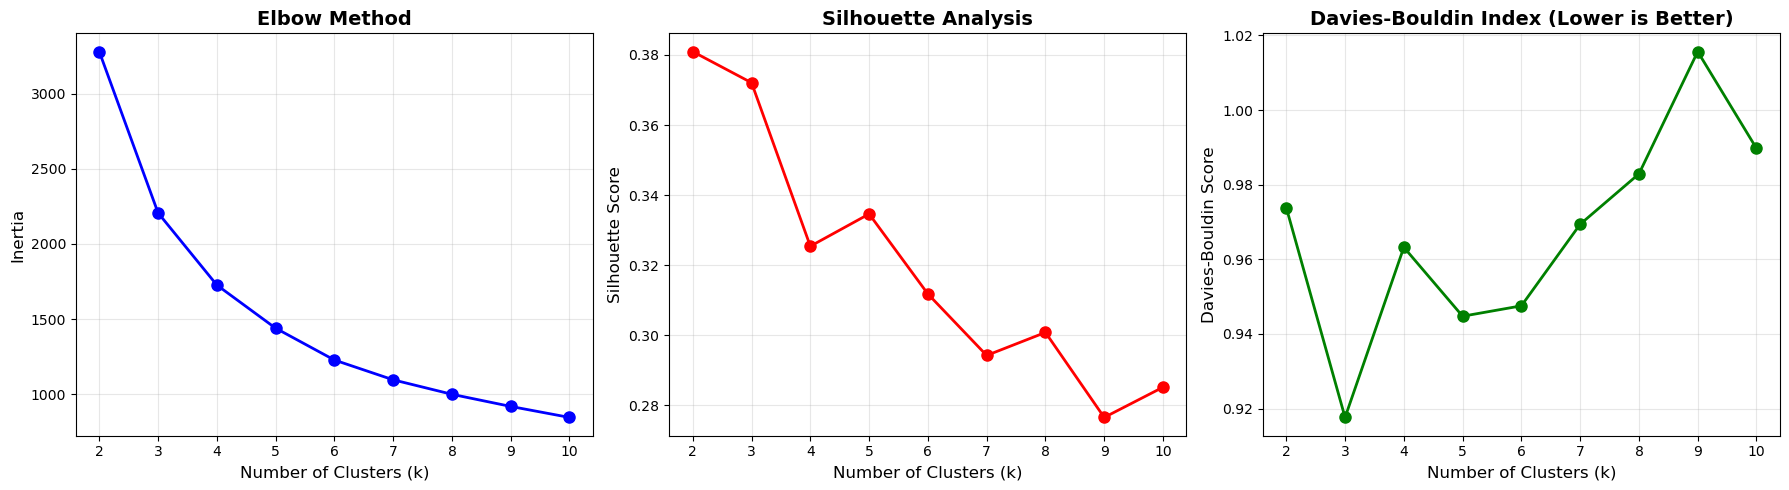


 Clustering Evaluation Metrics:
k=2: Inertia=3281.33, Silhouette=0.3810, Davies-Bouldin=0.9739
k=3: Inertia=2207.13, Silhouette=0.3721, Davies-Bouldin=0.9176
k=4: Inertia=1726.30, Silhouette=0.3254, Davies-Bouldin=0.9632
k=5: Inertia=1438.91, Silhouette=0.3346, Davies-Bouldin=0.9447
k=6: Inertia=1226.81, Silhouette=0.3118, Davies-Bouldin=0.9475
k=7: Inertia=1095.01, Silhouette=0.2942, Davies-Bouldin=0.9694
k=8: Inertia=998.50, Silhouette=0.3008, Davies-Bouldin=0.9829
k=9: Inertia=917.71, Silhouette=0.2765, Davies-Bouldin=1.0156
k=10: Inertia=844.39, Silhouette=0.2851, Davies-Bouldin=0.9897

 Optimal k based on Silhouette Score: 2

 Applying K-Means with k=2...
✓ Clustering complete!
  - Silhouette Score: 0.3810
  - Davies-Bouldin Score: 0.9739


In [4]:
# ============================================================================
# 3. K-MEANS CLUSTERING
# ============================================================================

print("\n" + "="*80)
print("K-MEANS CLUSTERING")
print("="*80)

# Prepare data for clustering
clustering_features = ['Recency', 'Frequency', 'Monetary']
X = rfm[clustering_features].values

print(f"\nFeatures for clustering: {clustering_features}")
print(f"Data shape: {X.shape}")

# Standardize features (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✓ Features standardized")

# Determine optimal number of clusters using Elbow Method and Silhouette Score
print("\n Determining Optimal Number of Clusters...")

inertias = []
silhouette_scores = []
davies_bouldin_scores = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, kmeans.labels_))

# Plot evaluation metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow Method
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Davies-Bouldin Score (lower is better)
axes[2].plot(K_range, davies_bouldin_scores, 'go-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[2].set_ylabel('Davies-Bouldin Score', fontsize=12)
axes[2].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/18_optimal_clusters.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 18_optimal_clusters.png")
plt.show()

print("\n Clustering Evaluation Metrics:")
for k, inertia, sil_score, db_score in zip(K_range, inertias, silhouette_scores, davies_bouldin_scores):
    print(f"k={k}: Inertia={inertia:.2f}, Silhouette={sil_score:.4f}, Davies-Bouldin={db_score:.4f}")

# Choose optimal k (typically where silhouette score is highest and elbow occurs)
optimal_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\n Optimal k based on Silhouette Score: {optimal_k}")

# Apply K-Means with optimal k
print(f"\n Applying K-Means with k={optimal_k}...")
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
rfm['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"✓ Clustering complete!")
print(f"  - Silhouette Score: {silhouette_score(X_scaled, rfm['Cluster']):.4f}")
print(f"  - Davies-Bouldin Score: {davies_bouldin_score(X_scaled, rfm['Cluster']):.4f}")

In [8]:
# ============================================================================
# 4. CLUSTER PROFILING
# ============================================================================

print("\n" + "="*80)
print("CLUSTER PROFILING AND CHARACTERIZATION")
print("="*80)

# Cluster statistics
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': ['mean', 'std'],
    'Frequency': ['mean', 'std'],
    'Monetary': ['mean', 'std'],
    'Customer_ID': 'count'
}).round(2)

cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns.values]
cluster_summary = cluster_summary.rename(columns={'Customer_ID_count': 'Customer_Count'})
cluster_summary['Customer_Percentage'] = (cluster_summary['Customer_Count'] / 
                                          cluster_summary['Customer_Count'].sum() * 100).round(2)

print("\n Cluster Summary Statistics:")
print(cluster_summary)

# Name clusters based on characteristics
def name_cluster_characteristics(cluster_data):
    """Assign meaningful names to clusters"""
    names = {}
    
    for cluster_id in cluster_data.index:
        r_mean = cluster_data.loc[cluster_id, 'Recency_mean']
        f_mean = cluster_data.loc[cluster_id, 'Frequency_mean']
        m_mean = cluster_data.loc[cluster_id, 'Monetary_mean']
        
        # Define thresholds (adjust based on your data)
        r_threshold = cluster_data['Recency_mean'].median()
        f_threshold = cluster_data['Frequency_mean'].median()
        m_threshold = cluster_data['Monetary_mean'].median()
        
        if r_mean < r_threshold and f_mean > f_threshold and m_mean > m_threshold:
            names[cluster_id] = 'VIP Customers'
        elif f_mean > f_threshold and m_mean > m_threshold:
            names[cluster_id] = 'High Value'
        elif r_mean < r_threshold and f_mean <= f_threshold:
            names[cluster_id] = 'Potential'
        else:
            names[cluster_id] = 'At Risk'
    
    return names
    
cluster_names = name_cluster_characteristics(cluster_summary)
rfm['Cluster_Name'] = rfm['Cluster'].map(cluster_names)

print("\n Cluster Names:")
for cluster_id, name in cluster_names.items():
    count = cluster_summary.loc[cluster_id, 'Customer_Count']
    pct = cluster_summary.loc[cluster_id, 'Customer_Percentage']
    print(f"  Cluster {cluster_id}: {name} ({count:.0f} customers, {pct:.1f}%)")

# Detailed profiling report
print("\n" + "="*80)
print("DETAILED CLUSTER PROFILES")
print("="*80)

for cluster_id, cluster_name in cluster_names.items():
    cluster_data = rfm[rfm['Cluster'] == cluster_id]
    total_revenue = cluster_data['Monetary'].sum()
    revenue_share = (total_revenue / rfm['Monetary'].sum() * 100)
    
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_id}: {cluster_name}")
    print(f"{'='*60}")
    print(f"Size: {len(cluster_data):,} customers ({len(cluster_data)/len(rfm)*100:.1f}%)")
    print(f"\nRFM Metrics:")
    print(f"  • Avg Recency: {cluster_data['Recency'].mean():.1f} days")
    print(f"  • Avg Frequency: {cluster_data['Frequency'].mean():.1f} orders")
    print(f"  • Avg Monetary: ${cluster_data['Monetary'].mean():,.2f}")
    print(f"  • Total Revenue: ${total_revenue:,.2f} ({revenue_share:.1f}% of total)")
    
    print(f"\nRecommended Marketing Actions:")
    if cluster_name == 'VIP Customers':
        print("  ✓ Exclusive rewards and early access to new products")
        print("  ✓ Personalized communication and dedicated support")
        print("  ✓ Premium tier membership programs")
        print("  ✓ Referral incentives")
    elif cluster_name == 'High Value':
        print("  ✓ Loyalty programs with tiered benefits")
        print("  ✓ Cross-sell and upsell campaigns")
        print("  ✓ Regular engagement through email marketing")
        print("  ✓ Special occasion offers")
    elif cluster_name == 'Potential':
        print("  ✓ Nurture with targeted promotions")
        print("  ✓ Product recommendations based on browsing")
        print("  ✓ Time-limited offers to encourage repeat purchase")
        print("  ✓ Educational content about products")
    else:  # At Risk
        print("  ✓ Win-back campaigns with special discounts")
        print("  ✓ Survey to understand reasons for churn")
        print("  ✓ Re-engagement through personalized content")
        print("  ✓ Abandoned cart reminders")

# Save cluster profiling
rfm.to_csv('data/processed/customer_segments.csv', index=False)
print("\n✓ Customer segments saved to: data/processed/customer_segments.csv")


CLUSTER PROFILING AND CHARACTERIZATION

 Cluster Summary Statistics:
         Recency_mean  Recency_std  Frequency_mean  Frequency_std  \
Cluster                                                             
0               45.81        39.95            6.89           1.67   
1              112.75        87.40            3.42           1.24   

         Monetary_mean  Monetary_std  Customer_Count  Customer_Percentage  
Cluster                                                                    
0               772.36        217.65             924                46.53  
1               343.70        148.98            1062                53.47  

 Cluster Names:
  Cluster 0: VIP Customers (924 customers, 46.5%)
  Cluster 1: At Risk (1062 customers, 53.5%)

DETAILED CLUSTER PROFILES

CLUSTER 0: VIP Customers
Size: 924 customers (46.5%)

RFM Metrics:
  • Avg Recency: 45.8 days
  • Avg Frequency: 6.9 orders
  • Avg Monetary: $772.36
  • Total Revenue: $713,663.99 (66.2% of total)

Recommende

In [9]:
# ============================================================================
# 5. CLUSTER VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print("CLUSTER VISUALIZATION")
print("="*80)

# 5.1 PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

rfm['PCA1'] = X_pca[:, 0]
rfm['PCA2'] = X_pca[:, 1]

explained_var = pca.explained_variance_ratio_
print(f"\nPCA Explained Variance:")
print(f"  PC1: {explained_var[0]*100:.2f}%")
print(f"  PC2: {explained_var[1]*100:.2f}%")
print(f"  Total: {sum(explained_var)*100:.2f}%")
# 2D Scatter plot
fig = px.scatter(rfm, x='PCA1', y='PCA2', color='Cluster_Name',
                 title='Customer Segments Visualization (PCA)',
                 labels={'PCA1': f'PC1 ({explained_var[0]:.2%} variance)',
                         'PCA2': f'PC2 ({explained_var[1]:.2%} variance)'},
                 hover_data=['Recency', 'Frequency', 'Monetary', 'Customer_ID'],
                 color_discrete_sequence=px.colors.qualitative.Set2)
fig.write_html('outputs/figures/19_customer_segments_pca.html')
print("✓ Saved: 19_customer_segments_pca.html")

# 5.2 3D visualization in RFM space
fig = px.scatter_3d(rfm, x='Recency', y='Frequency', z='Monetary',
                    color='Cluster_Name',
                    title='Customer Segments in RFM Space',
                    labels={'Recency': 'Recency (days)', 
                            'Frequency': 'Frequency (orders)',
                            'Monetary': 'Monetary ($)'},
                    hover_data=['Customer_ID'],
                    color_discrete_sequence=px.colors.qualitative.Pastel)
fig.write_html('outputs/figures/20_customer_segments_3d.html')
print("✓ Saved: 20_customer_segments_3d.html")

# 5.3 Segment size and revenue contribution
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=('Customer Count by Segment', 'Revenue by Segment'),
                    specs=[[{'type': 'bar'}, {'type': 'bar'}]])

segment_counts = rfm['Cluster_Name'].value_counts()
segment_revenue = rfm.groupby('Cluster_Name')['Monetary'].sum().sort_values(ascending=False)

fig.add_trace(go.Bar(x=segment_counts.index, y=segment_counts.values, 
                     name='Customers', marker_color='lightblue'), row=1, col=1)
fig.add_trace(go.Bar(x=segment_revenue.index, y=segment_revenue.values, 
                     name='Revenue', marker_color='lightcoral'), row=1, col=2)

fig.update_xaxes(title_text="Segment", row=1, col=1)
fig.update_xaxes(title_text="Segment", row=1, col=2)
fig.update_yaxes(title_text="Number of Customers", row=1, col=1)
fig.update_yaxes(title_text="Total Revenue ($)", row=1, col=2)
fig.update_layout(height=500, showlegend=False, title_text="Segment Distribution")

fig.write_html('outputs/figures/21_segment_distribution.html')
print("✓ Saved: 21_segment_distribution.html")


CLUSTER VISUALIZATION

PCA Explained Variance:
  PC1: 70.72%
  PC2: 24.52%
  Total: 95.24%
✓ Saved: 19_customer_segments_pca.html
✓ Saved: 20_customer_segments_3d.html
✓ Saved: 21_segment_distribution.html



COHORT ANALYSIS

Total Cohorts: 14

Cohort Sizes:
Cohort
2022-10    27
2022-11    25
2022-12     9
2023-01    11
2023-02     6
Freq: M, Name: Customer_ID, dtype: int64

 Cohort Retention Rates (%):
Cohort_Index     0          1          2          3          4          5   \
Cohort                                                                       
2022-01       100.0  26.821192  31.622517  29.139073  31.125828  32.615894   
2022-02       100.0  30.886076  28.860759  28.354430  35.443038  29.620253   
2022-03       100.0  31.615120  32.302405  30.927835  32.646048  28.522337   
2022-04       100.0  32.352941  24.019608  29.901961  31.372549  27.450980   
2022-05       100.0  34.074074  28.888889  32.592593  25.925926  34.074074   

Cohort_Index         6          7          8          9          10  \
Cohort                                                                
2022-01       30.463576  31.291391  26.324503  31.953642  29.635762   
2022-02       30.379747  34.683544  31.64

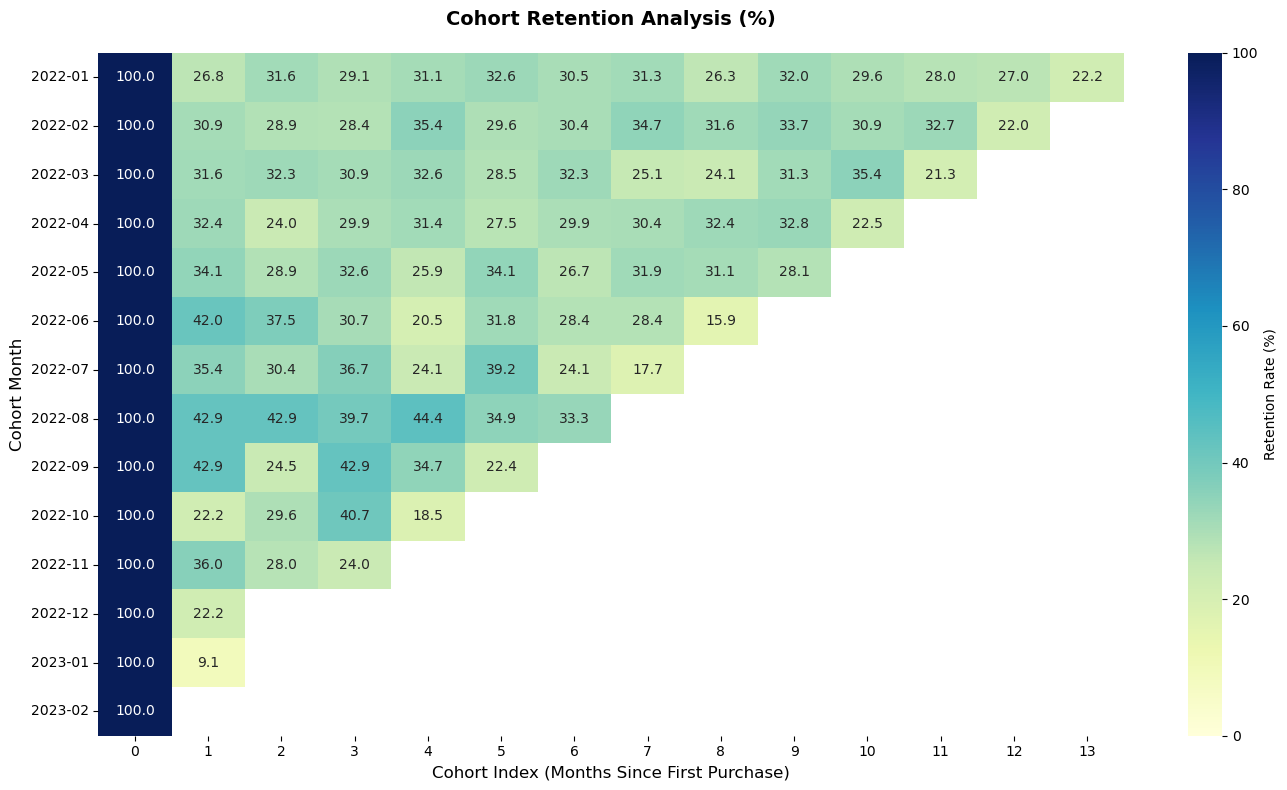

✓ Cohort data saved to: outputs/reports/cohort_retention.csv


In [12]:
# ============================================================================
# 6. COHORT ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("COHORT ANALYSIS")
print("="*80)

# Create cohort data
df_cohort = df.copy()
df_cohort['Order_Month'] = df_cohort['Order_Date'].dt.to_period('M')
df_cohort['Cohort'] = df_cohort.groupby('Customer_ID')['Order_Date'].transform('min').dt.to_period('M')

# Calculate cohort index (months since first purchase)
def get_cohort_period(df):
    df['Cohort_Index'] = (df['Order_Month'] - df['Cohort']).apply(lambda x: x.n)
    return df

df_cohort = get_cohort_period(df_cohort)

# Cohort size
cohort_size = df_cohort.groupby('Cohort')['Customer_ID'].nunique()
print(f"\nTotal Cohorts: {len(cohort_size)}")
print("\nCohort Sizes:")
print(cohort_size.tail())
# Retention matrix
retention = df_cohort.groupby(['Cohort', 'Cohort_Index'])['Customer_ID'].nunique().reset_index()
retention_matrix = retention.pivot(index='Cohort', columns='Cohort_Index', values='Customer_ID')

# Calculate retention rate
retention_rate = retention_matrix.divide(cohort_size, axis=0) * 100

print("\n Cohort Retention Rates (%):")
print(retention_rate.head())

# Visualize cohort retention
plt.figure(figsize=(14, 8))
sns.heatmap(retention_rate, annot=True, fmt='.1f', cmap='YlGnBu', 
            cbar_kws={'label': 'Retention Rate (%)'}, vmin=0, vmax=100)
plt.title('Cohort Retention Analysis (%)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Cohort Index (Months Since First Purchase)', fontsize=12)
plt.ylabel('Cohort Month', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/figures/23_cohort_retention.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 23_cohort_retention.png")
plt.show()

# Save cohort data
retention_rate.to_csv('outputs/reports/cohort_retention.csv')
print("✓ Cohort data saved to: outputs/reports/cohort_retention.csv")

In [13]:
# ============================================================================
# 7. CUSTOMER LIFETIME VALUE (CLV)
# ============================================================================

print("\n" + "="*80)
print("CUSTOMER LIFETIME VALUE (CLV) CALCULATION")
print("="*80)

# Calculate CLV components
customer_metrics = df.groupby('Customer_ID').agg({
    'Sales': 'sum',
    'Order_ID': 'count',
    'Order_Date': ['min', 'max']
}).reset_index()

customer_metrics.columns = ['Customer_ID', 'Total_Revenue', 'Order_Count', 
                            'First_Purchase', 'Last_Purchase']

# Convert to datetime
customer_metrics['First_Purchase'] = pd.to_datetime(customer_metrics['First_Purchase'])
customer_metrics['Last_Purchase'] = pd.to_datetime(customer_metrics['Last_Purchase'])
# Calculate customer lifespan
customer_metrics['Lifespan_Days'] = (customer_metrics['Last_Purchase'] - 
                                      customer_metrics['First_Purchase']).dt.days
customer_metrics['Lifespan_Days'] = customer_metrics['Lifespan_Days'].replace(0, 1)  # Avoid division by zero

# Calculate metrics
customer_metrics['Avg_Order_Value'] = customer_metrics['Total_Revenue'] / customer_metrics['Order_Count']
customer_metrics['Purchase_Frequency'] = customer_metrics['Order_Count'] / (customer_metrics['Lifespan_Days'] / 365.25)

# Simple CLV calculation
# CLV = Average Order Value × Purchase Frequency × Average Customer Lifespan (in years)
avg_customer_lifespan_years = 3  # Assumption
customer_metrics['CLV_Simple'] = (customer_metrics['Avg_Order_Value'] * 
                                   customer_metrics['Purchase_Frequency'] * 
                                   avg_customer_lifespan_years)

print(f"\n CLV Summary Statistics:")
print(customer_metrics['CLV_Simple'].describe())

# Categorize customers by CLV
customer_metrics['CLV_Category'] = pd.qcut(customer_metrics['CLV_Simple'], 
                                            q=4, 
                                            labels=['Low', 'Medium', 'High', 'Very High'],
                                            duplicates='drop')

print("\n CLV Distribution:")
print(customer_metrics['CLV_Category'].value_counts())
# Visualize CLV distribution
fig = px.histogram(customer_metrics, x='CLV_Simple', 
                   title='Customer Lifetime Value Distribution',
                   nbins=50,
                   labels={'CLV_Simple': 'CLV ($)'},
                   color_discrete_sequence=['steelblue'])
fig.add_vline(x=customer_metrics['CLV_Simple'].median(), line_dash="dash", 
              line_color="red", annotation_text=f"Median: ${customer_metrics['CLV_Simple'].median():,.2f}")
fig.write_html('outputs/figures/24_clv_distribution.html')
print("✓ Saved: 24_clv_distribution.html")

# CLV by segment
clv_by_category = customer_metrics.groupby('CLV_Category').agg({
    'Customer_ID': 'count',
    'CLV_Simple': 'mean',
    'Total_Revenue': 'sum',
    'Order_Count': 'mean'
}).round(2)
clv_by_category.columns = ['Customer_Count', 'Avg_CLV', 'Total_Revenue', 'Avg_Orders']

print("\n CLV Summary by Category:")
print(clv_by_category)

# Save CLV data
customer_metrics.to_csv('data/processed/customer_clv.csv', index=False)
print("\n✓ CLV data saved to: data/processed/customer_clv.csv")
print("\n" + "="*80)
print("NOTEBOOK 04 COMPLETED SUCCESSFULLY!")
print("="*80)
print("\n Next Step: Open Notebook 05 - KPI Design and Dashboard Preparation")
print("="*80)


CUSTOMER LIFETIME VALUE (CLV) CALCULATION

 CLV Summary Statistics:
count      1986.000000
mean       7521.286062
std       27172.675182
min         253.804359
25%        1701.373520
50%        2340.984912
75%        3334.635156
max      301695.484146
Name: CLV_Simple, dtype: float64

 CLV Distribution:
CLV_Category
Low          497
Very High    497
Medium       496
High         496
Name: count, dtype: int64
✓ Saved: 24_clv_distribution.html

 CLV Summary by Category:
              Customer_Count   Avg_CLV  Total_Revenue  Avg_Orders
CLV_Category                                                     
Low                      497   1241.72      163187.25        3.86
Medium                   496   2024.10      258937.03        5.09
High                     496   2767.70      341005.29        6.17
Very High                497  24031.00      315541.42        5.03

✓ CLV data saved to: data/processed/customer_clv.csv

NOTEBOOK 04 COMPLETED SUCCESSFULLY!

 Next Step: Open Notebook 05 - KPI Des